In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR

import sys
sys.path.append("../src")
from GAKELM import GeneticELMRegressor

In [24]:
np.set_printoptions(suppress=True)
RANDOM_STATE = 42

In [38]:
dataset = pd.read_csv("../data/Dataset.csv")


In [37]:
print("Rows:", dataset.shape[0], "| Columns:", dataset.shape[1])

print("\nDataset columns:")
print(list(dataset.columns.tolist()))

print()
dataset.info()

Rows: 502 | Columns: 16

Dataset columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        502 non-null    object 
 1   Date        502 non-null    object 
 2   PM2.5       279 non-null    float64
 3   PM10        0 non-null      float64
 4   NO          305 non-null    float64
 5   NO2         306 non-null    float64
 6   NOx         306 non-null    float64
 7   NH3         0 non-null      float64
 8   CO          305 non-null    float64
 9   SO2         306 non-null    float64
 10  O3          304 non-null    float64
 11  Benzene     306 non-null    float64
 12  Toluene     306 non-null    float64
 13  Xylene      306 non-null    float64
 14  AQI         263 non-null    float64
 15  AQI_Bucket  263 n

In [27]:
dataset.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [28]:
def interpolate_nans(X):
    """Overwrite NaNs with column-wise linear interpolation."""
    X = np.asarray(X, dtype=float).copy()
    for j in range(X.shape[1]):
        mask_j = np.isnan(X[:, j])
        if not mask_j.any():
            continue
        if mask_j.all():
            X[:, j] = 0.0 
            continue
        X[mask_j, j] = np.interp(np.flatnonzero(mask_j),
                                 np.flatnonzero(~mask_j),
                                 X[~mask_j, j])
    return X


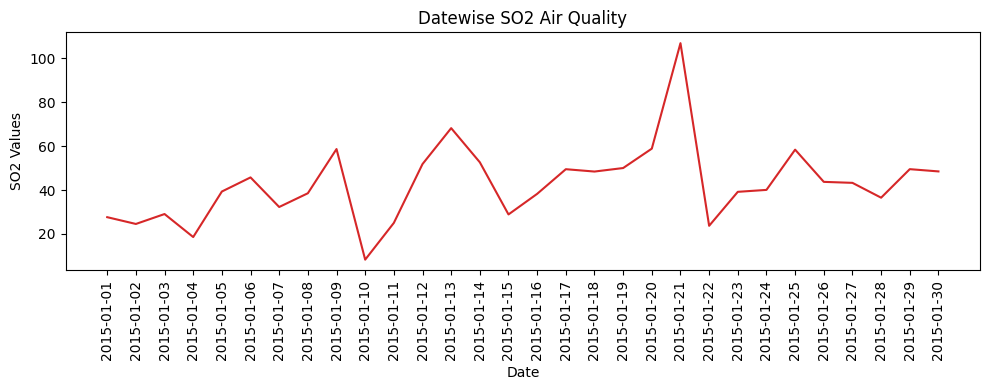

In [29]:
plt.figure(figsize=(10, 4), dpi=100)
plt.plot(dataset.Date[0:30], dataset.SO2[0:30], color="tab:red")
plt.gca().set(title="Datewise SO2 Air Quality", xlabel="Date", ylabel="SO2 Values")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [30]:
TARGET = "PM2.5"

LEAKY_OR_NON_NUMERIC = ["City", "Date", "AQI", "AQI_Bucket", TARGET]

feature_cols = [c for c in dataset.columns if c not in LEAKY_OR_NON_NUMERIC]
print("Target   :", TARGET)
print("Features :", feature_cols)


data = dataset.dropna(subset=[TARGET]).reset_index(drop=True)
print(f"\nDropped {len(dataset) - len(data)} rows with a missing target.")

X = interpolate_nans(data[feature_cols].to_numpy(dtype=float))
Y = data[[TARGET]].to_numpy(dtype=float)

print("X shape:", X.shape, "| Y shape:", Y.shape)
assert not np.isnan(X).any(), "NaNs remain in X"


Target   : PM2.5
Features : ['PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

Dropped 223 rows with a missing target.
X shape: (279, 11) | Y shape: (279, 1)


In [31]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, Y, test_size=0.2, random_state=RANDOM_STATE
)

sc1 = MinMaxScaler(feature_range=(0, 1))  
sc2 = MinMaxScaler(feature_range=(0, 1)) 

X_train = sc1.fit_transform(X_train_raw)
X_test = sc1.transform(X_test_raw)

y_train = sc2.fit_transform(y_train_raw)
y_test = sc2.transform(y_test_raw)

print("Total records found in dataset  = " + str(X.shape[0]))
print("Total features found in dataset = " + str(X.shape[1]))
print("80% dataset for training : " + str(X_train.shape[0]))
print("20% dataset for testing  : " + str(X_test.shape[0]))


Total records found in dataset  = 279
Total features found in dataset = 11
80% dataset for training : 223
20% dataset for testing  : 56


In [32]:
results_store = {}


def calculateMetrics(algorithm, predict, test_labels, scaler=None):
    """Report MSE/RMSE in normalized space and, if a scaler is given, in real units."""
    predict = np.asarray(predict, dtype=float).reshape(-1, 1)
    test_labels = np.asarray(test_labels, dtype=float).reshape(-1, 1)

    mse_value = mean_squared_error(test_labels, predict)
    rmse_value = float(np.sqrt(mse_value))

    row = {"MSE": mse_value, "RMSE": rmse_value}
    print(f"{algorithm} MSE  : {mse_value:.6f}")
    print(f"{algorithm} RMSE : {rmse_value:.6f}")

    if scaler is not None:
        pred_u = scaler.inverse_transform(predict)
        true_u = scaler.inverse_transform(test_labels)
        rmse_u = float(np.sqrt(mean_squared_error(true_u, pred_u)))
        row["RMSE (target units)"] = rmse_u
        print(f"{algorithm} RMSE : {rmse_u:.4f} (original units)")

    results_store[algorithm] = row


In [33]:

svm_cls = SVR()
svm_cls.fit(X_train, y_train.ravel())
predict = svm_cls.predict(X_test)
calculateMetrics("SVR", predict, y_test, scaler=sc2)


SVR MSE  : 0.015620
SVR RMSE : 0.124980
SVR RMSE : 29.4166 (original units)


In [34]:
elm = GeneticELMRegressor()
elm.fit(X_train, y_train.ravel())
predict = elm.predict(X_test)
calculateMetrics("GA-KELM", predict, y_test, scaler=sc2)


GA-KELM MSE  : 0.013065
GA-KELM RMSE : 0.114301
GA-KELM RMSE : 26.9029 (original units)


,MSE,RMSE,RMSE (target units)
Algorithm,,,
SVR,0.015620,0.124980,29.416609
GA-KELM,0.013065,0.114301,26.902926


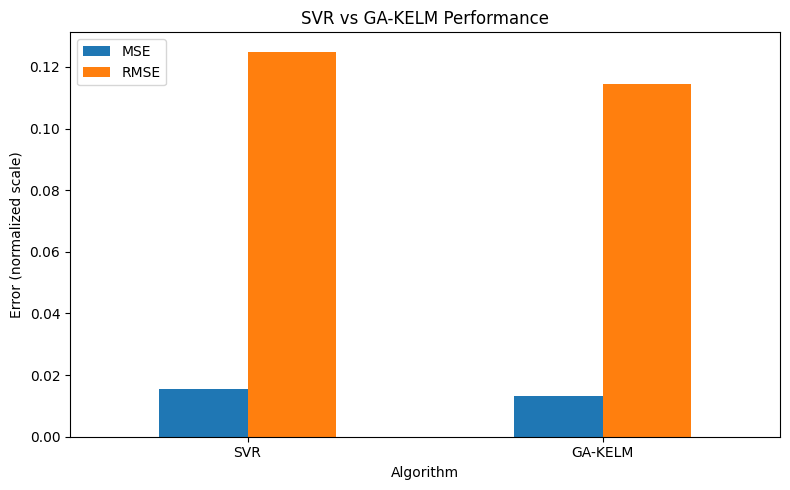

In [36]:
results = pd.DataFrame(results_store).T.rename_axis("Algorithm")
display(results)

results[["MSE", "RMSE"]].plot(kind="bar", figsize=(8, 5))
plt.title("SVR vs GA-KELM Performance")
plt.ylabel("Error (normalized scale)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
